In [1]:
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
from torch import tensor as tt

import sys as sys
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
import math 
import re
from scipy.spatial import distance_matrix
from sklearn.metrics.pairwise import euclidean_distances 
import pandas as pd
import netCDF4 as nc


In [2]:
def Energy_Score(energy_beta, observations_y, simulations_Y):
    m = len(simulations_Y)
    diff_Y_y = torch.pow(
        torch.norm(
            (observations_y.unsqueeze(1) -
             simulations_Y.unsqueeze(0)).float(),
            dim=2, keepdim=True).reshape(-1, 1),
        energy_beta)
    diff_Y_Y = 2 * torch.pow(
        nn.functional.pdist(simulations_Y),
        energy_beta)
    Energy = 2 * torch.mean(diff_Y_y) - torch.sum(diff_Y_Y) / (m * (m - 1))
    return Energy

def torch_Matern_05(dist_matrix, rho):
    K = torch.exp(-dist_matrix / rho)
    return K

def sample_Gauss_fixed_noise(fixed_noise, chol_cov):
    return fixed_noise @ chol_cov.T

def revert_to_indep_gauss(dependent_samples, chol_cov):
    return dependent_samples @ torch.linalg.inv(chol_cov).T

norm = torch.distributions.Normal(0.0, 1.0)


# Simulating data

D [[ 0.         10.         14.14213562]
 [10.          0.         10.        ]
 [14.14213562 10.          0.        ]]
Cov tensor([[1.0000, 0.7515, 0.6676],
        [0.7515, 1.0000, 0.7515],
        [0.6676, 0.7515, 1.0000]], dtype=torch.float64)


C:\Users\u1819911\AppData\Local\Temp\ipykernel_19380\1100401450.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  latent_x_censored = np.maximum(latent_x,censor_lvl)


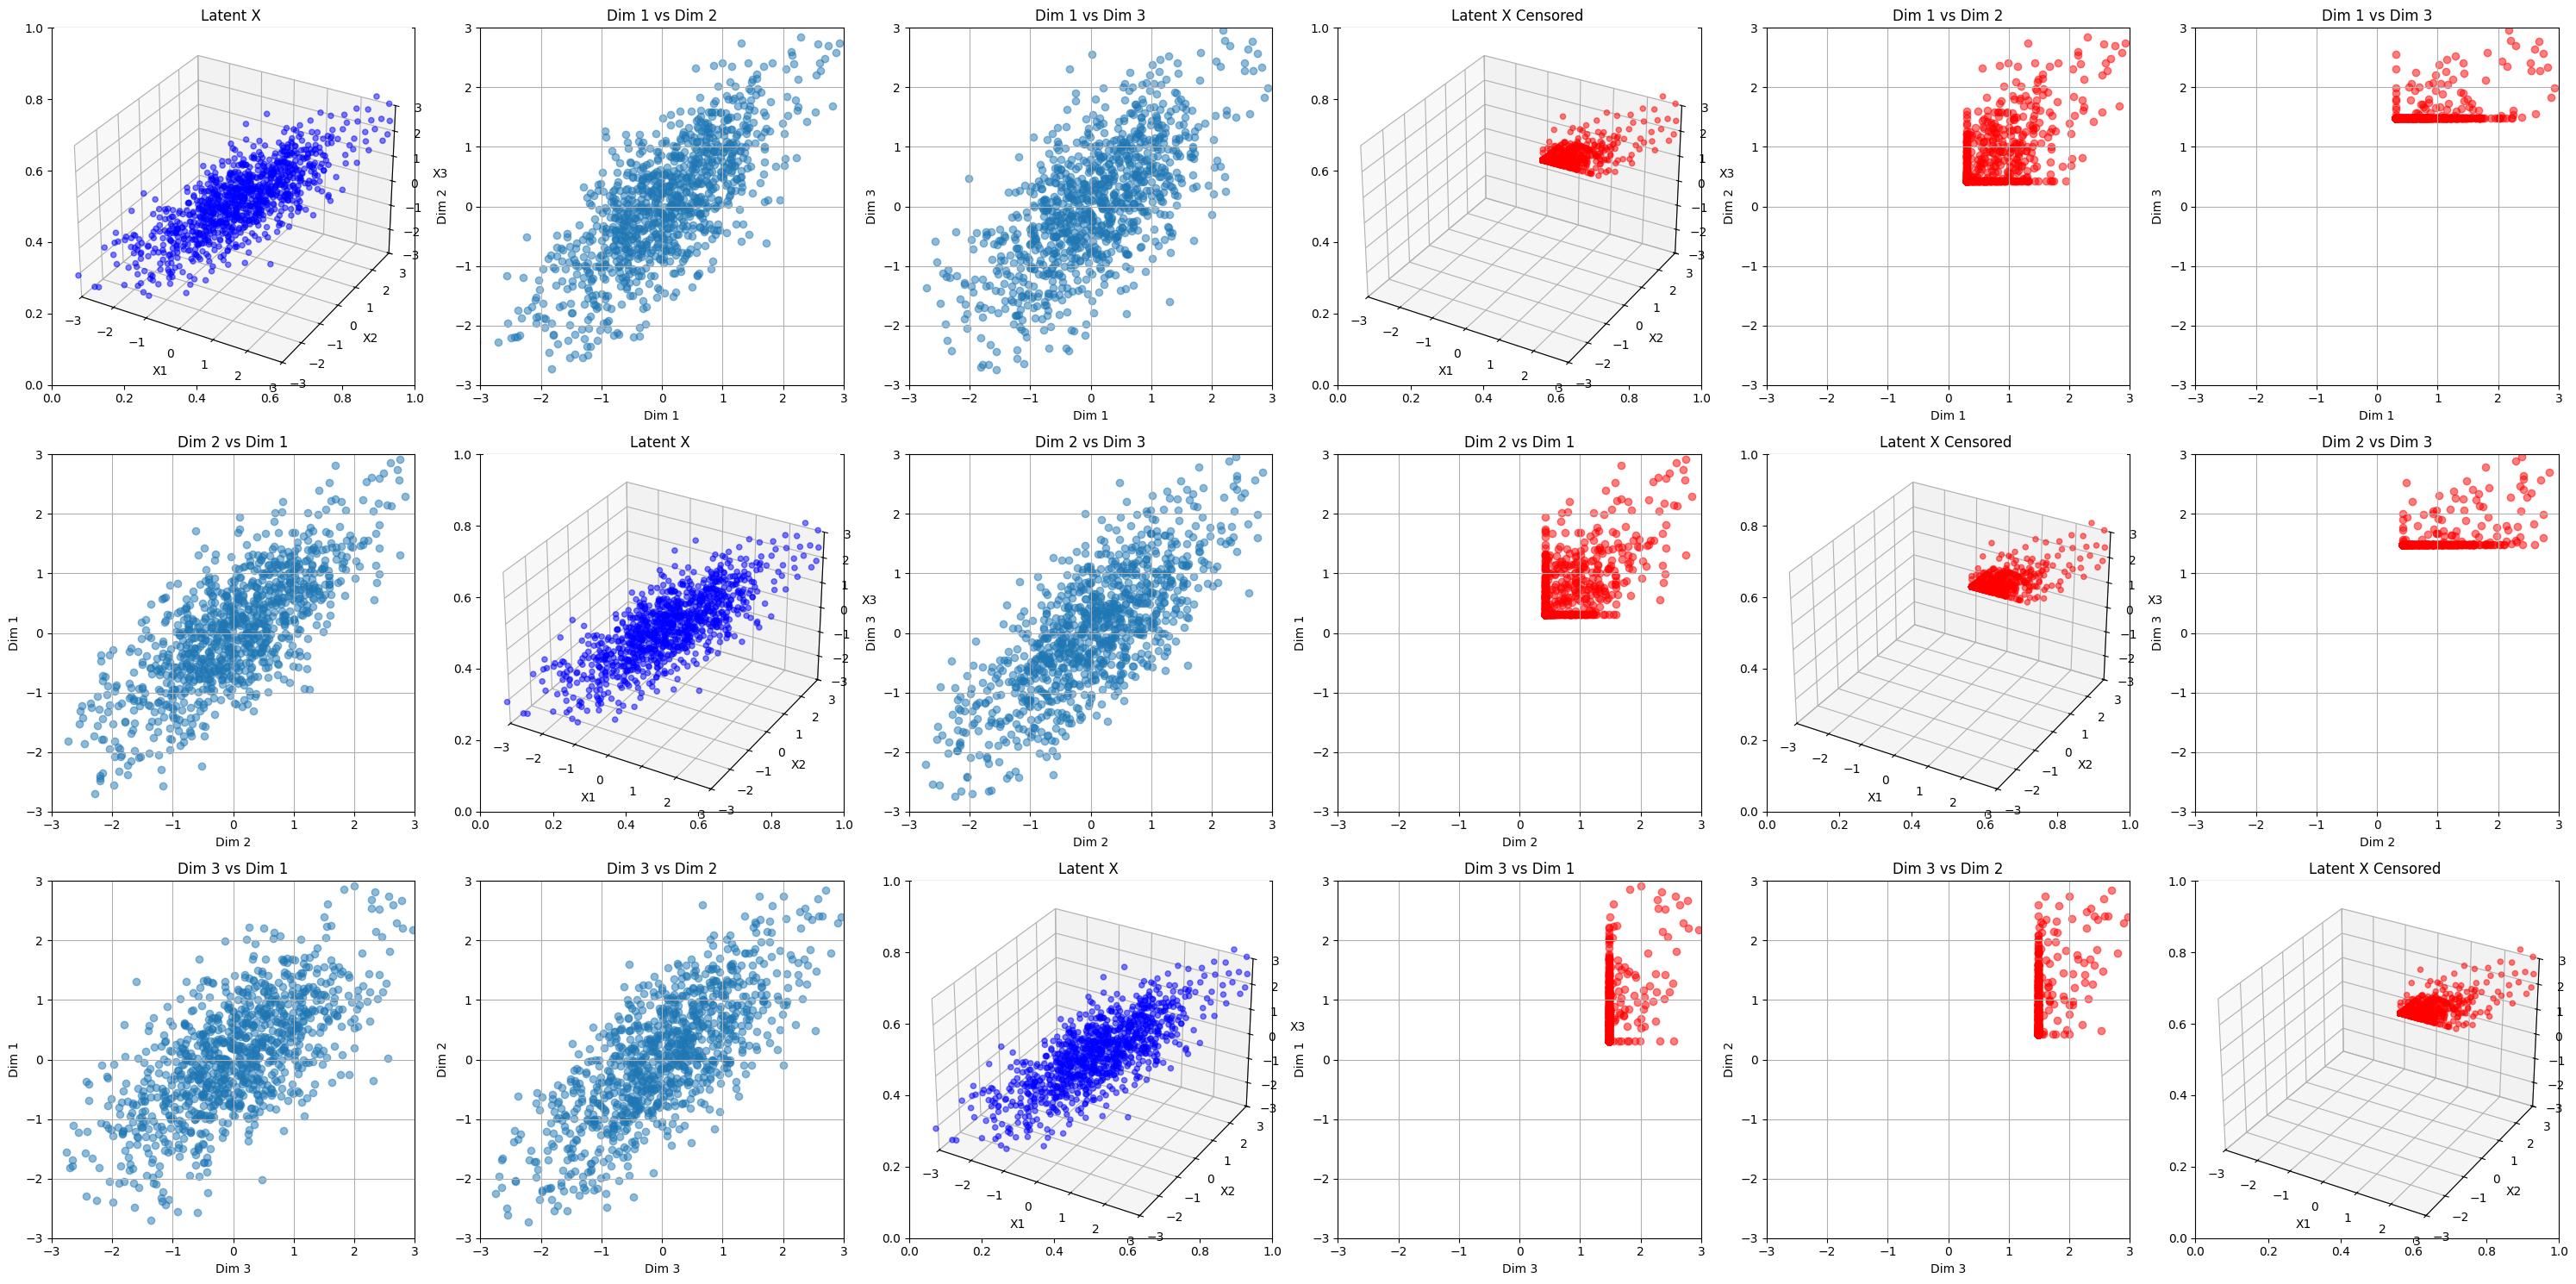

C:\Users\u1819911\AppData\Local\Temp\ipykernel_19380\1100401450.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  latent_x_censored = tt(latent_x_censored)


In [3]:
dist_mat = np.matrix([[0,1,np.sqrt(2)],[1,0,1],[np.sqrt(2),1,0]])*10
print('D',dist_mat)



true_cov = torch_Matern_05(tt(dist_mat), 35.0)
print('Cov',true_cov)

# Gaussian copula
latent_x = scs.multivariate_normal.rvs(mean=np.zeros(true_cov.shape[0]), cov=true_cov, size=1000)
copula_u = scs.norm.cdf(latent_x)



# Censored Gaussian copula
censor_lvl = torch.randn(1, true_cov.shape[0])
latent_x_censored = np.maximum(latent_x,censor_lvl)
copula_u_censored = scs.norm.cdf(latent_x_censored)


# Create a 3x6 subplot
fig, axes = plt.subplots(3, 6, figsize=(30, 15))

# Plot pair relationships and 3D scatter plots on the diagonal for latent_x
for i in range(3):
    for j in range(3):
        if i == j:
            # 3D scatter plot on the diagonal
            ax = fig.add_subplot(3, 6, i * 6 + j + 1, projection='3d')
            ax.scatter(latent_x[:, 0], latent_x[:, 1], latent_x[:, 2], c='b', marker='o', alpha=0.5)
            ax.set_title(f'Latent X ')
            ax.set_xlabel('X1')
            ax.set_ylabel('X2')
            ax.set_zlabel('X3')
            ax.set_xlim(-3, 3)
            ax.set_ylim(-3, 3)
            ax.set_zlim(-3, 3)
        else:
            # 2D scatter plot for pair relationships
            ax = axes[i, j]
            ax.scatter(latent_x[:, i], latent_x[:, j], alpha=0.5)
            ax.set_title(f'Dim {i+1} vs Dim {j+1}')
            ax.set_xlabel(f'Dim {i+1}')
            ax.set_ylabel(f'Dim {j+1}')
            ax.set_xlim(-3, 3)
            ax.set_ylim(-3, 3)
            ax.grid(True)

# Plot pair relationships and 3D scatter plots on the diagonal for latent_x_censored
for i in range(3):
    for j in range(3):
        if i == j:
            # 3D scatter plot on the diagonal
            ax = fig.add_subplot(3, 6, i * 6 + j + 4, projection='3d')
            ax.scatter(latent_x_censored[:, 0], latent_x_censored[:, 1], latent_x_censored[:, 2], c='r', marker='o', alpha=0.5)
            ax.set_title(f'Latent X Censored ')
            ax.set_xlabel('X1')
            ax.set_ylabel('X2')
            ax.set_zlabel('X3')
            ax.set_xlim(-3, 3)
            ax.set_ylim(-3, 3)
            ax.set_zlim(-3, 3)
        else:
            # 2D scatter plot for pair relationships
            ax = axes[i, j + 3]
            ax.scatter(latent_x_censored[:, i], latent_x_censored[:, j], alpha=0.5, c='r')
            ax.set_title(f'Dim {i+1} vs Dim {j+1}')
            ax.set_xlabel(f'Dim {i+1}')
            ax.set_ylabel(f'Dim {j+1}')
            ax.set_xlim(-3, 3)
            ax.set_ylim(-3, 3)
            ax.grid(True)

plt.tight_layout()
plt.show()

latent_x = tt(latent_x)
copula_u = tt(copula_u)
latent_x_censored = tt(latent_x_censored)
copula_u_censored = tt(copula_u_censored)


# Direct Gaussian

In [18]:
theta_est = tt(torch.rand(1)*10.).to(dtype=torch.float32)+30
theta_est.requires_grad = True
dist_mat = tt(dist_mat)

epochs = 100
fixed_noise = norm.sample(latent_x.shape).to(dtype=torch.float32)

history = torch.zeros((epochs,2))
optimizer = torch.optim.Adam([theta_est], lr=0.1)

for i in tqdm(range(epochs)):
    optimizer.zero_grad()
    cov_est = torch_Matern_05(dist_mat, theta_est)
    chol_cov_est = torch.linalg.cholesky(cov_est).to(dtype=torch.float32)
    dependent_samples = sample_Gauss_fixed_noise(fixed_noise, chol_cov_est)
    loss = Energy_Score(0.5, latent_x, dependent_samples)
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        history[i,0] = loss.item()
        history[i,1] = theta_est.item()


C:\Users\u1819911\AppData\Local\Temp\ipykernel_19380\1066451527.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_est = tt(torch.rand(1)*10.).to(dtype=torch.float32)+30
C:\Users\u1819911\AppData\Local\Temp\ipykernel_19380\1066451527.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dist_mat = tt(dist_mat)
100%|██████████| 100/100 [00:05<00:00, 18.02it/s]


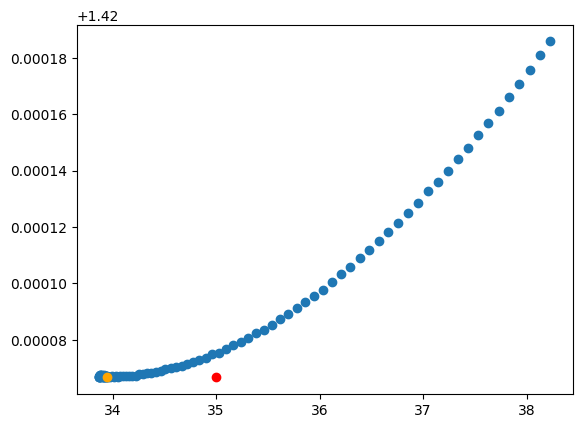

In [19]:
plt.scatter(history[:,1], history[:,0])
plt.scatter(history[-1,1], history[-1,0], c='orange')
plt.scatter(35.0, Energy_Score(0.5, latent_x, dependent_samples).item(), c='r')

In [36]:
(true_cov - torch_Matern_05(dist_mat, theta_est)).abs()

tensor([[0.0000, 0.0097, 0.0122],
        [0.0097, 0.0000, 0.0097],
        [0.0122, 0.0097, 0.0000]], dtype=torch.float64, grad_fn=<AbsBackward0>)

In [33]:
(true_cov - torch_Matern_05(dist_mat, theta_est)).abs().sum()

tensor(0.0634, dtype=torch.float64, grad_fn=<SumBackward0>)

In [35]:
torch.linalg.norm(true_cov - torch_Matern_05(dist_mat, theta_est)).sqrt()

tensor(0.1614, dtype=torch.float64, grad_fn=<SqrtBackward0>)

C:\Users\u1819911\AppData\Local\Temp\ipykernel_19380\4073231797.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_cov = torch_Matern_05(tt(dist_mat), true_theta)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_19380\4073231797.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dist_mat = tt(dist_mat)


n_obs 250


  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\u1819911\AppData\Local\Temp\ipykernel_19380\4073231797.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_est = tt(torch.rand(1)*10).to(dtype=torch.float32)+30.
100%|██████████| 1000/1000 [05:33<00:00,  3.00it/s]


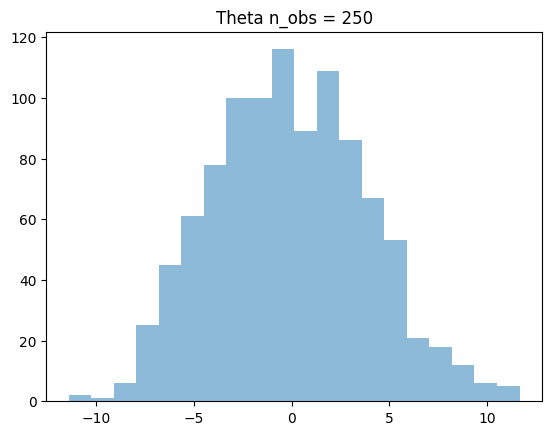

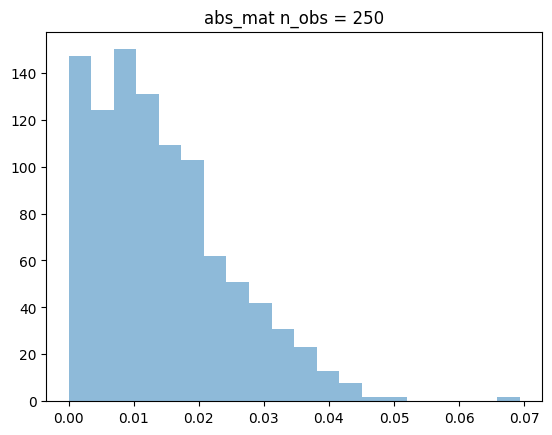

n_obs 500


100%|██████████| 1000/1000 [19:33<00:00,  1.17s/it]


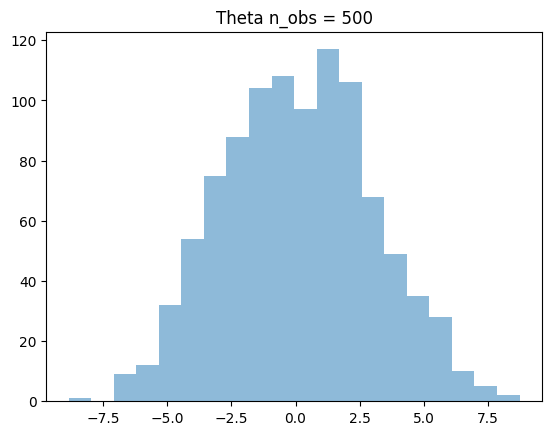

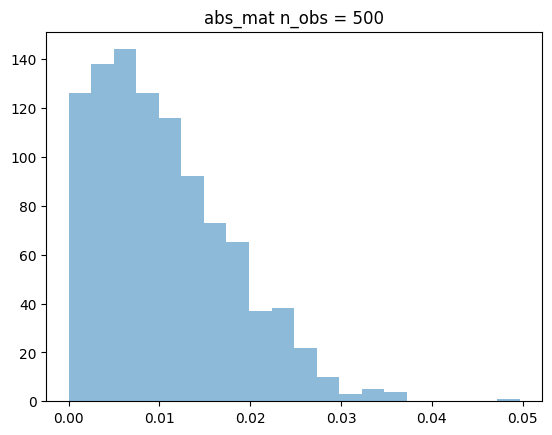

n_obs 750


100%|██████████| 1000/1000 [45:45<00:00,  2.75s/it]


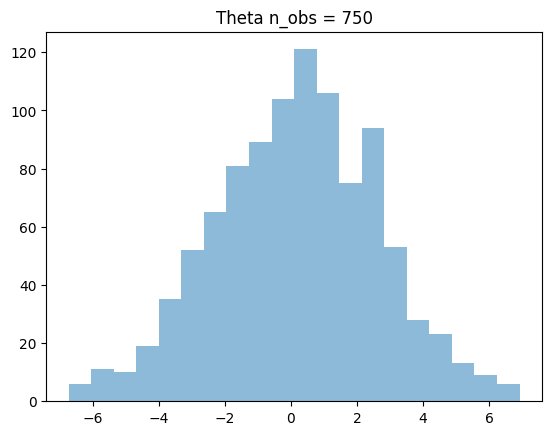

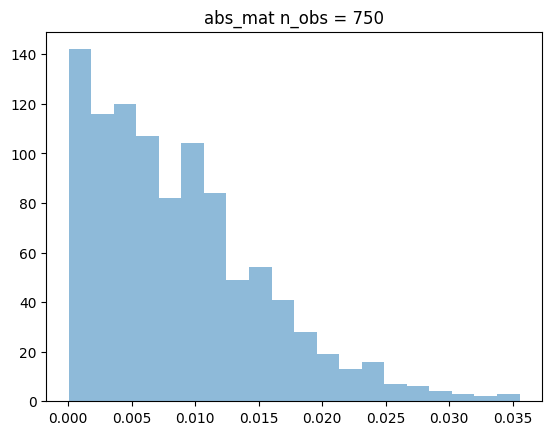

n_obs 1000


100%|██████████| 1000/1000 [1:22:22<00:00,  4.94s/it]


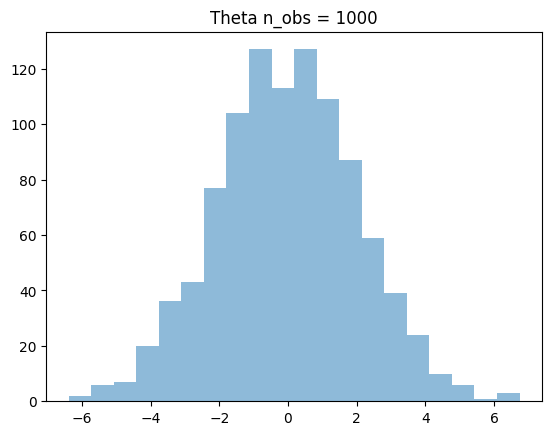

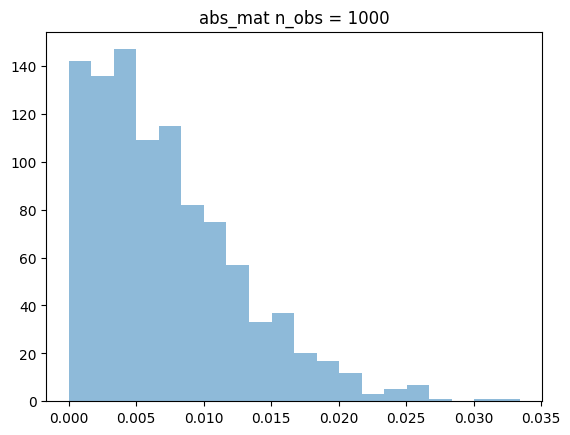

In [40]:
true_theta = 35.0
true_cov = torch_Matern_05(tt(dist_mat), true_theta)



theta_list_uncensored_50 = np.zeros((4,1000))
Absolute_mat_diff_list_uncensored_50 = np.zeros((4,1000))
theta_list_uncensored_100 = np.zeros((4,1000))
Absolute_mat_diff_list_uncensored_100 = np.zeros((4,1000))

dist_mat = tt(dist_mat)

for rep_n in range(4):
    # sample size
    n_obs = [250, 500, 750, 1000][rep_n]
    print('n_obs',n_obs)

    for rep_clt in tqdm(range(theta_list_uncensored_50.shape[1])):
        # initialize theta
        theta_est = tt(torch.rand(1)*10).to(dtype=torch.float32)+30.
        theta_est.requires_grad = True

        # sample from true copula
        latent_x = tt(scs.multivariate_normal.rvs(mean=np.zeros(true_cov.shape[0]), cov=true_cov, size=n_obs))

        epochs = 100
        fixed_noise = norm.sample(latent_x.shape).to(dtype=torch.float32)

        optimizer = torch.optim.Adam([theta_est], lr=0.1)

        for i in (range(epochs)):
            optimizer.zero_grad()
            cov_est = torch_Matern_05(dist_mat, theta_est)
            chol_cov_est = torch.linalg.cholesky(cov_est).to(dtype=torch.float32)
            dependent_samples_ = sample_Gauss_fixed_noise(fixed_noise, chol_cov_est)
            loss = Energy_Score(0.5, latent_x, dependent_samples_)
            loss.backward()
            optimizer.step()

            if i == 50:
                with torch.no_grad():
                    theta_list_uncensored_50[rep_n,rep_clt] = theta_est.item()
                    Absolute_mat_diff_list_uncensored_50[rep_n,rep_clt] = (true_cov - torch_Matern_05(dist_mat, theta_est)).abs().mean().item()
            if i == 99:
                with torch.no_grad():
                    theta_list_uncensored_100[rep_n,rep_clt] = theta_est.item()
                    Absolute_mat_diff_list_uncensored_100[rep_n,rep_clt] = (true_cov - torch_Matern_05(dist_mat, theta_est)).abs().mean().item()

    plt.hist((theta_list_uncensored_100[rep_n,:]-true_theta), bins=20, alpha=0.5)
    plt.title(f'Theta n_obs = {n_obs}')
    plt.show()
    plt.hist(Absolute_mat_diff_list_uncensored_100[rep_n,:], bins=20, alpha=0.5)
    plt.title(f'abs_mat n_obs = {n_obs}')
    plt.show()


np.save('theta_list_uncensored_50.npy',theta_list_uncensored_50)
np.save('theta_list_uncensored_100.npy',theta_list_uncensored_100)  
np.save('Absolute_mat_diff_list_uncensored_50.npy',Absolute_mat_diff_list_uncensored_50)
np.save('Absolute_mat_diff_list_uncensored_100.npy',Absolute_mat_diff_list_uncensored_100)

C:\Users\u1819911\AppData\Local\Temp\ipykernel_19380\2222821231.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


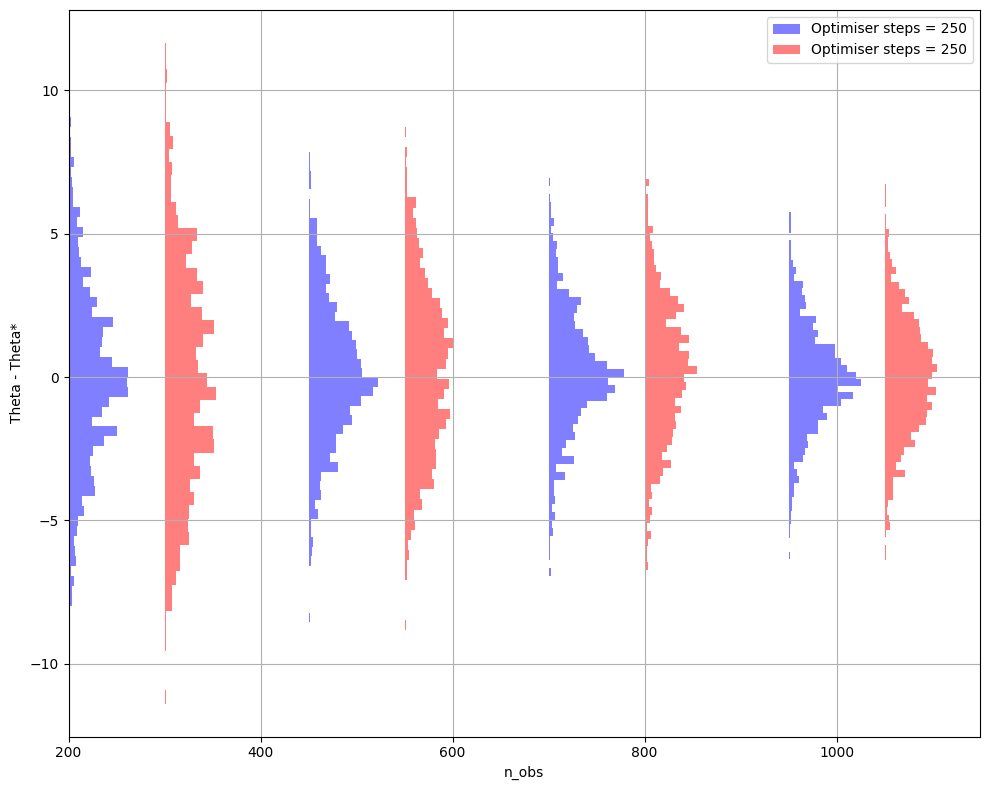

In [41]:
n_obs_values = [250, 500, 750, 1000]

# Create a figure with a single subplot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot histograms vertically for theta_list_uncensored_50 and theta_list_uncensored_100
for k in range(4):
    # Histogram for theta_list_uncensored_50
    hist_data_50 = theta_list_uncensored_50[k, :] - 35
    hist_50, bins_50 = np.histogram(hist_data_50, bins=50)
    bin_centers_50 = 0.5 * (bins_50[:-1] + bins_50[1:])
    if k==0:
        ax.barh(bin_centers_50, hist_50, height=(bins_50[1] - bins_50[0]), left=n_obs_values[k] - 50, alpha=0.5, label=f'Optimiser steps = {n_obs_values[k]}', color='blue')
    else:
        ax.barh(bin_centers_50, hist_50, height=(bins_50[1] - bins_50[0]), left=n_obs_values[k] - 50, alpha=0.5, color='blue')
    # Histogram for theta_list_uncensored_100
    hist_data_100 = theta_list_uncensored_100[k, :] - 35
    hist_100, bins_100 = np.histogram(hist_data_100, bins=50)
    bin_centers_100 = 0.5 * (bins_100[:-1] + bins_100[1:])
    if k==0:
        ax.barh(bin_centers_100, hist_100, height=(bins_100[1] - bins_100[0]), left=n_obs_values[k] + 50, alpha=0.5, label=f'Optimiser steps = {n_obs_values[k]}', color='red')
    else:
        ax.barh(bin_centers_100, hist_100, height=(bins_100[1] - bins_100[0]), left=n_obs_values[k] + 50, alpha=0.5, color='red')

ax.set_xlabel('n_obs')
ax.set_ylabel('Theta - Theta*')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# Censored Gaussian

In [ ]:
torch.rand(1, true_cov.shape[0])*3 - 1.5

C:\Users\u1819911\AppData\Local\Temp\ipykernel_19380\3345893250.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_cov = torch_Matern_05(tt(dist_mat), true_theta)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_19380\3345893250.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dist_mat = tt(dist_mat)


n_obs 250


  0%|          | 0/1000 [00:00<?, ?it/s]C:\Users\u1819911\AppData\Local\Temp\ipykernel_19380\3345893250.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_est = tt(torch.rand(1)*10).to(dtype=torch.float32)+30.
C:\Users\u1819911\AppData\Local\Temp\ipykernel_19380\3345893250.py:24: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  latent_x_censored = np.maximum(latent_x,censor_lvl)
100%|██████████| 1000/1000 [05:56<00:00,  2.80it/s]


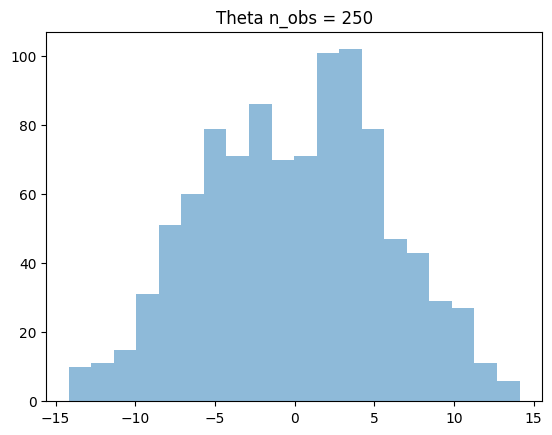

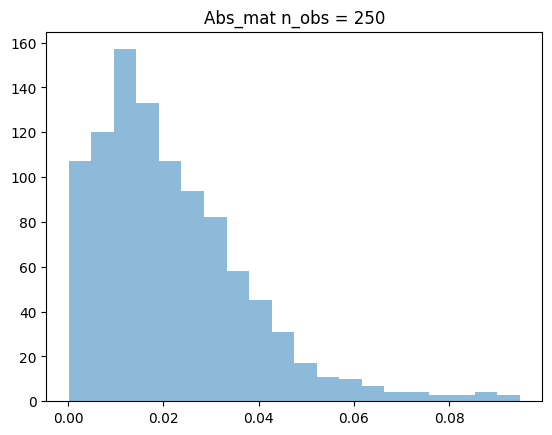

n_obs 500


100%|██████████| 1000/1000 [21:13<00:00,  1.27s/it]


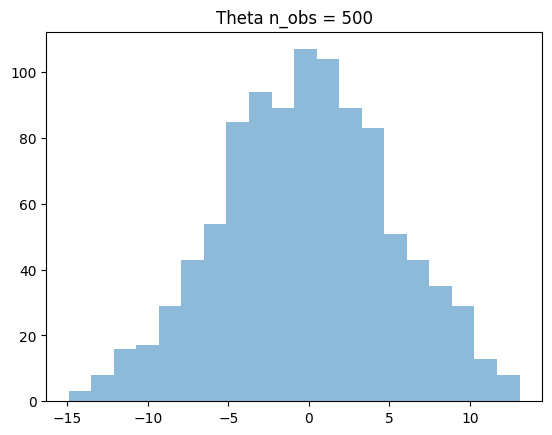

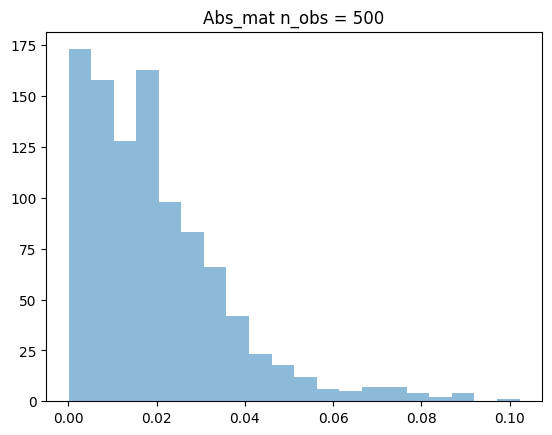

n_obs 750


100%|██████████| 1000/1000 [47:16<00:00,  2.84s/it]


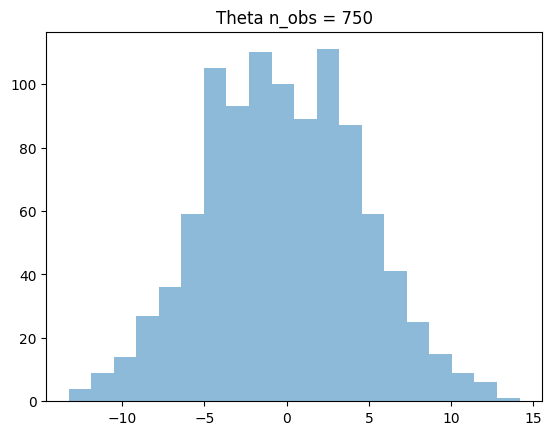

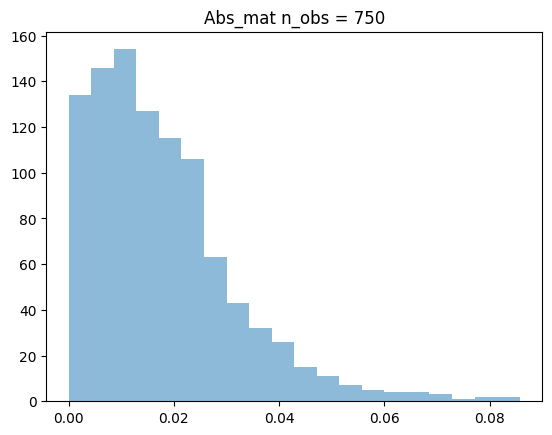

n_obs 1000


100%|██████████| 1000/1000 [1:23:08<00:00,  4.99s/it]


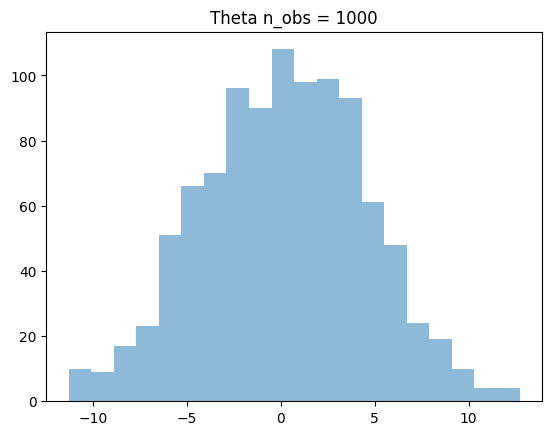

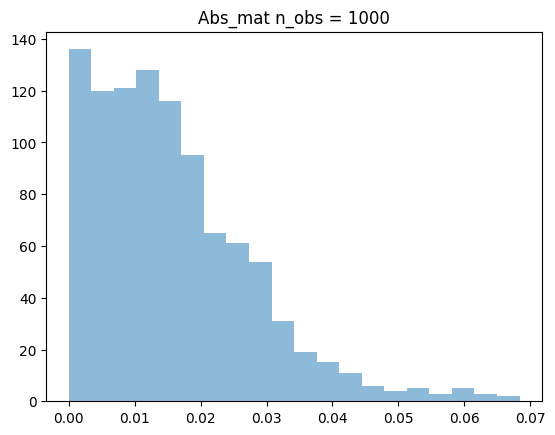

In [39]:
true_theta = 35.0
true_cov = torch_Matern_05(tt(dist_mat), true_theta)

theta_list_censored_50 = np.zeros((4,1000))
Absolute_mat_diff_list_censored_50 = np.zeros((4,1000))
theta_list_censored_100 = np.zeros((4,1000))
Absolute_mat_diff_list_censored_100 = np.zeros((4,1000))

dist_mat = tt(dist_mat)


for rep_n in range(4):
    n_obs = [250, 500, 750, 1000][rep_n]
    print('n_obs',n_obs)

    for rep_clt in tqdm(range(theta_list_censored_100.shape[1])):
        theta_est = tt(torch.rand(1)*10).to(dtype=torch.float32)+30.
        theta_est.requires_grad = True

        # sample from true copula
        latent_x = tt(scs.multivariate_normal.rvs(mean=np.zeros(true_cov.shape[0]), cov=true_cov, size=n_obs))
        # Censored Gaussian copula
        censor_lvl = torch.rand(1, true_cov.shape[0])*3 - 1.5
        latent_x_censored = np.maximum(latent_x,censor_lvl)

        epochs = 100
        fixed_noise = norm.sample(latent_x.shape).to(dtype=torch.float32)

        optimizer = torch.optim.Adam([theta_est], lr=0.1)

        for i in (range(epochs)):
            optimizer.zero_grad()
            cov_est = torch_Matern_05(dist_mat, theta_est)
            chol_cov_est = torch.linalg.cholesky(cov_est).to(dtype=torch.float32)
            dependent_samples_ = sample_Gauss_fixed_noise(fixed_noise, chol_cov_est)
            dependent_samples_censored = torch.maximum(dependent_samples_, censor_lvl)
            loss = Energy_Score(0.5, latent_x_censored, dependent_samples_censored)
            loss.backward()
            optimizer.step()

            if i == 50:
                with torch.no_grad():
                    theta_list_censored_50[rep_n,rep_clt] = theta_est.item()
                    Absolute_mat_diff_list_censored_50[rep_n,rep_clt] = (true_cov - torch_Matern_05(dist_mat, theta_est)).abs().mean().item()
            if i == 99:
                with torch.no_grad():
                    theta_list_censored_100[rep_n,rep_clt] = theta_est.item()
                    Absolute_mat_diff_list_censored_100[rep_n,rep_clt] = (true_cov - torch_Matern_05(dist_mat, theta_est)).abs().mean().item()

    plt.hist((theta_list_censored_100[rep_n,:]-35), bins=20, alpha=0.5)
    plt.title(f'Theta n_obs = {n_obs}')
    plt.show()
    plt.hist(Absolute_mat_diff_list_censored_100[rep_n,:], bins=20, alpha=0.5)
    plt.title(f'Abs_mat n_obs = {n_obs}')
    plt.show()

np.save('theta_list_censored_50.npy',theta_list_censored_50)
np.save('theta_list_censored_100.npy',theta_list_censored_100)
np.save('Absolute_mat_diff_list_censored_50.npy',Absolute_mat_diff_list_censored_50)
np.save('Absolute_mat_diff_list_censored_100.npy',Absolute_mat_diff_list_censored_100)

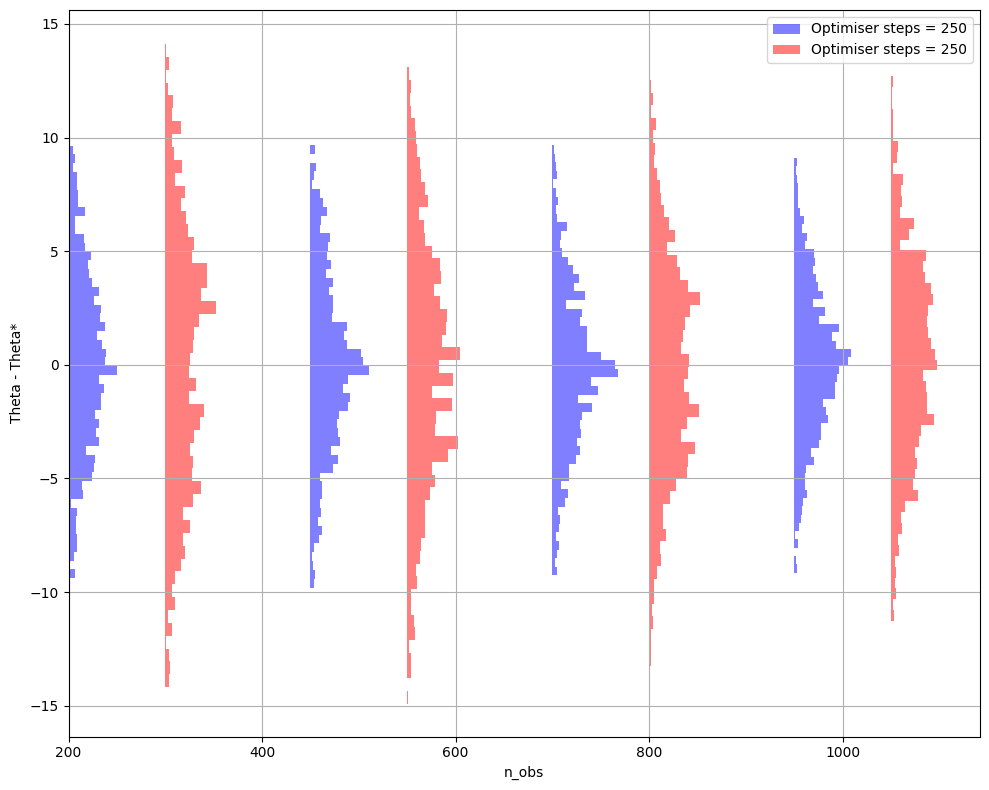

In [156]:
n_obs_values = [250, 500, 750, 1000]

# Create a figure with a single subplot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot histograms vertically for theta_list_censored_50 and theta_list_censored_100
for k in range(4):
    # Histogram for theta_list_censored_50
    hist_data_50 = theta_list_censored_50[k, :] - 35
    hist_50, bins_50 = np.histogram(hist_data_50, bins=50)
    bin_centers_50 = 0.5 * (bins_50[:-1] + bins_50[1:])
    if k==0:
        ax.barh(bin_centers_50, hist_50, height=(bins_50[1] - bins_50[0]), left=n_obs_values[k] - 50, alpha=0.5, label=f'Optimiser steps = {n_obs_values[k]}', color='blue')
    else:
        ax.barh(bin_centers_50, hist_50, height=(bins_50[1] - bins_50[0]), left=n_obs_values[k] - 50, alpha=0.5, color='blue')
    # Histogram for theta_list_censored_100
    hist_data_100 = theta_list_censored_100[k, :] - 35
    hist_100, bins_100 = np.histogram(hist_data_100, bins=50)
    bin_centers_100 = 0.5 * (bins_100[:-1] + bins_100[1:])
    if k==0:
        ax.barh(bin_centers_100, hist_100, height=(bins_100[1] - bins_100[0]), left=n_obs_values[k] + 50, alpha=0.5, label=f'Optimiser steps = {n_obs_values[k]}', color='red')
    else:
        ax.barh(bin_centers_100, hist_100, height=(bins_100[1] - bins_100[0]), left=n_obs_values[k] + 50, alpha=0.5, color='red')

ax.set_xlabel('n_obs')
ax.set_ylabel('Theta - Theta*')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

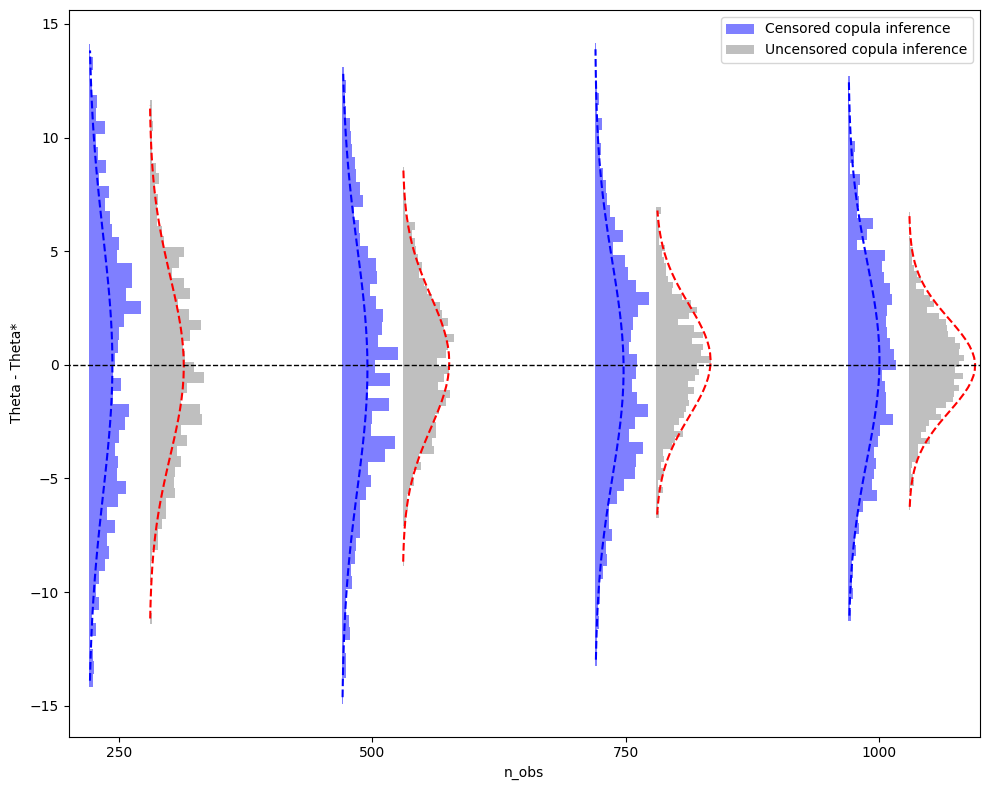

In [155]:
from scipy.stats import norm

n_obs_values = [250, 500, 750, 1000]

# Create a figure with a single subplot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot histograms vertically for theta_list_censored_50 and theta_list_censored_100
for k in range(4):
    # Histogram for theta_list_censored_100
    hist_data_100 = theta_list_censored_100[k, :] - 35
    hist_100, bins_100 = np.histogram(hist_data_100, bins=50)
    bin_centers_100 = 0.5 * (bins_100[:-1] + bins_100[1:])
     #plot a Gaussian density with mean and std given by the hist values for censored
    # Plot the Gaussian density
    mu_100, std_100 = norm.fit(hist_data_100)
    p_100 = norm.pdf(bin_centers_100, mu_100, std_100)*1000/3
    ax.plot(n_obs_values[k] - 30 + p_100 , bin_centers_100, color='blue', linestyle='--')

    if k==0:
        ax.barh(bin_centers_100, hist_100, height=(bins_100[1] - bins_100[0]), left=n_obs_values[k] -30, alpha=0.5, label=f'Censored copula inference', color='blue')
    else:
        ax.barh(bin_centers_100, hist_100, height=(bins_100[1] - bins_100[0]), left=n_obs_values[k] -30, alpha=0.5, color='blue')

    # Histogram for theta_list_censored_50
    #plot a Gaussian density with mean and std given by the hist values for censored
    hist_data_50 = theta_list_uncensored_100[k, :] - 35
    hist_50, bins_50 = np.histogram(hist_data_50, bins=50)
    bin_centers_50 = 0.5 * (bins_50[:-1] + bins_50[1:])

    mu_50, std_50 = norm.fit(hist_data_50)
    p_50 = norm.pdf(bin_centers_50, mu_50, std_50)*1000/3
    ax.plot(n_obs_values[k] + 30 + p_50 , bin_centers_50, color='red', linestyle='--')
    
    if k==0:
        ax.barh(bin_centers_50, hist_50, height=(bins_50[1] - bins_50[0]), left=n_obs_values[k] +30, alpha=0.5, label='Uncensored copula inference', color='grey')
    else:
        ax.barh(bin_centers_50, hist_50, height=(bins_50[1] - bins_50[0]), left=n_obs_values[k] +30, alpha=0.5, color='grey')

ax.hlines(0, 0, 1100, color='black', linewidth=1, linestyle='--')

ax.set_xticks(n_obs_values)
ax.set_xticklabels(n_obs_values)
ax.set_xlim(200, 1100)

ax.set_xlabel('n_obs')
ax.set_ylabel('Theta - Theta*')
ax.legend()


plt.tight_layout()
plt.show()

In [151]:
norm.fit(hist_data_100)

(np.float64(0.1986274528503418), np.float64(4.322759002073048))

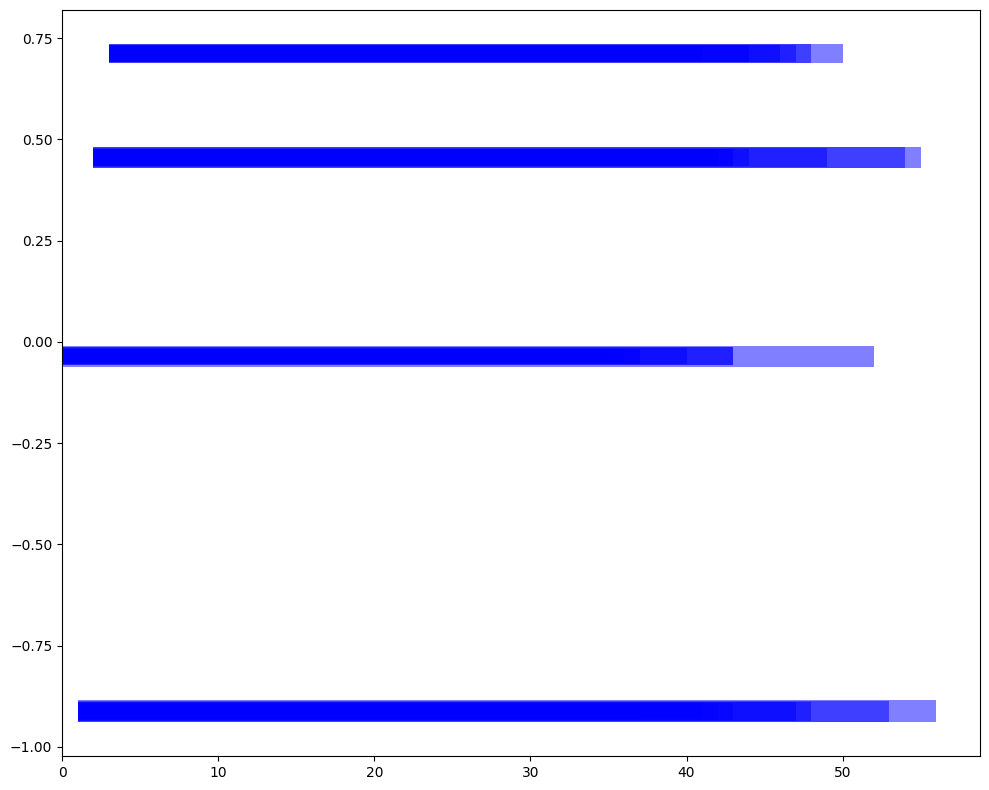

In [144]:
from scipy.stats import norm

n_obs_values = [250, 500, 750, 1000]

# Create a figure with a single subplot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot histograms vertically for theta_list_censored_50 and theta_list_censored_100
for k in range(4):
    # Histogram for theta_list_censored_100
    hist_data_100 = theta_list_censored_100[k, :] - 35
    hist_100, bins_100 = np.histogram(hist_data_100, bins=50)
    bin_centers_100 = bins_100.mean()    
    ax.barh(y=bin_centers_100, width= hist_100,height = hist_100/hist_100.sum(),  left=[0,1,2,3][k] , alpha=0.5, label=f'Optimiser steps = {n_obs_values[k]}', color='blue')

plt.tight_layout()
plt.show()

In [146]:
hist_100

array([ 3,  2,  5,  4,  5,  4,  8,  7, 11, 10, 14, 28, 23, 25, 27, 25, 29,
       31, 44, 37, 37, 36, 33, 47, 45, 41, 38, 37, 38, 43, 41, 35, 33, 36,
        9, 18, 24,  9, 11, 10, 12,  2,  6,  7,  2,  2,  2,  1,  1,  2])

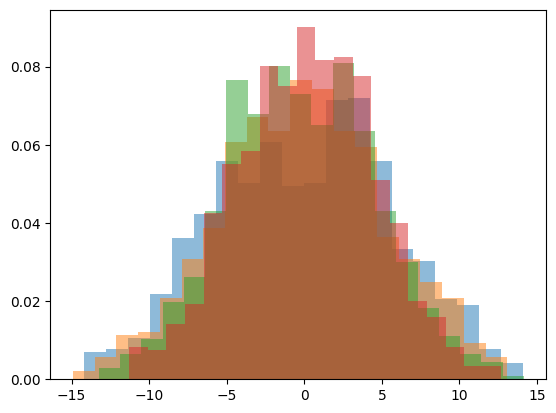

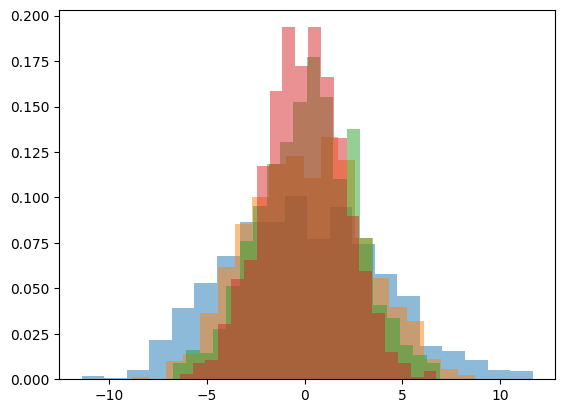

In [112]:
plt.hist(theta_list_censored_100[0]-35,density=True, bins=20, alpha=0.5)
plt.hist(theta_list_censored_100[1]-35,density=True, bins=20, alpha=0.5)
plt.hist(theta_list_censored_100[2]-35,density=True, bins=20, alpha=0.5)
plt.hist(theta_list_censored_100[3]-35,density=True, bins=20, alpha=0.5)
plt.show()
plt.hist(theta_list_uncensored_100[0]-35,density=True, bins=20, alpha=0.5)
plt.hist(theta_list_uncensored_100[1]-35,density=True, bins=20, alpha=0.5)
plt.hist(theta_list_uncensored_100[2]-35,density=True, bins=20, alpha=0.5)
plt.hist(theta_list_uncensored_100[3]-35,density=True, bins=20, alpha=0.5)
plt.show()

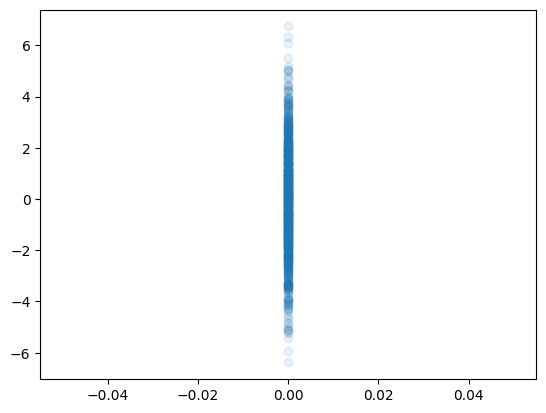

In [88]:
plt.scatter(np.zeros(hist_data_50.shape[0]),hist_data_50,alpha=0.1)

In [63]:
p_100

array([0.00356599, 0.00452072, 0.00567489, 0.0070539 , 0.00868206,
       0.01058128, 0.01276955, 0.01525932, 0.0180558 , 0.02115534,
       0.02454401, 0.02819635, 0.03207467, 0.0361288 , 0.04029645,
       0.04450431, 0.04866978, 0.05270339, 0.05651189, 0.06000162,
       0.06308239, 0.06567125, 0.06769622, 0.0690996 , 0.0698407 ,
       0.06989782, 0.06926928, 0.06797351, 0.06604815, 0.06354825,
       0.06054364, 0.0571157 , 0.05335368, 0.04935092, 0.045201  ,
       0.04099425, 0.03681457, 0.03273697, 0.02882566, 0.02513286,
       0.02169835, 0.01854955, 0.01570225, 0.01316172, 0.01092409,
       0.00897801, 0.00730628, 0.00588756, 0.00469781, 0.00371174])